=== Loaded Results ===

                        Precision@5  Recall@5    F1@5
Method                                               
Community-UU (Louvain)       0.4543    0.1582  0.2347
Community-II (Infomap)       0.4613    0.1204  0.1910
SVD+Louvain                  0.6302    0.1776  0.2771
ALS+Louvain                  0.6754    0.2556  0.3709
BM25+Louvain                 0.4643    0.1424  0.2180
SVD+Leiden                   0.6302    0.1776  0.2771
ALS+Leiden                   0.6754    0.2556  0.3709
BM25+Leiden                  0.4643    0.1424  0.2180
SVD+Infomap                  0.6231    0.1709  0.2683
ALS+Infomap                  0.6482    0.2258  0.3350
BM25+Infomap                 0.4633    0.1414  0.2167
SVD+FluidC                   0.6111    0.1622  0.2564
ALS+FluidC                   0.6342    0.2119  0.3177
BM25+FluidC                  0.4583    0.1356  0.2093




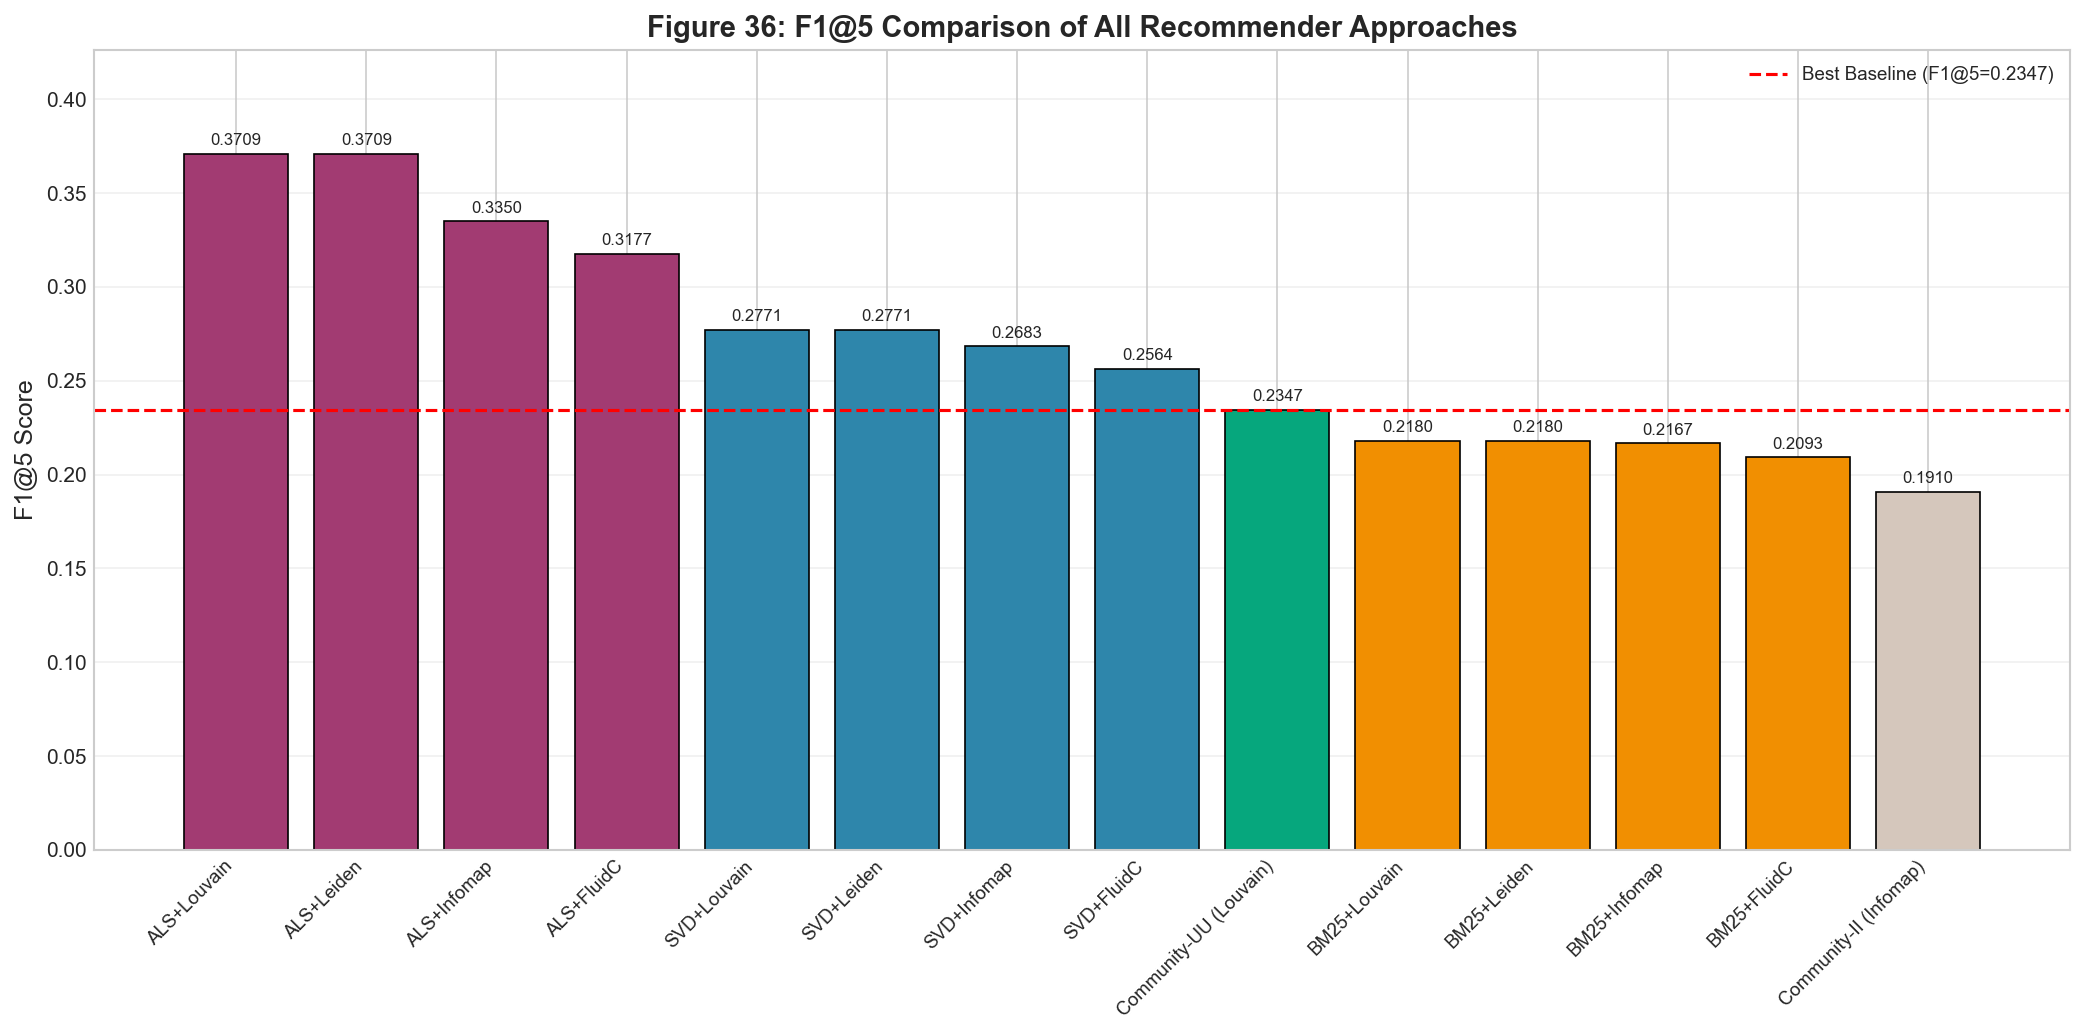

✓ Figure 36 saved



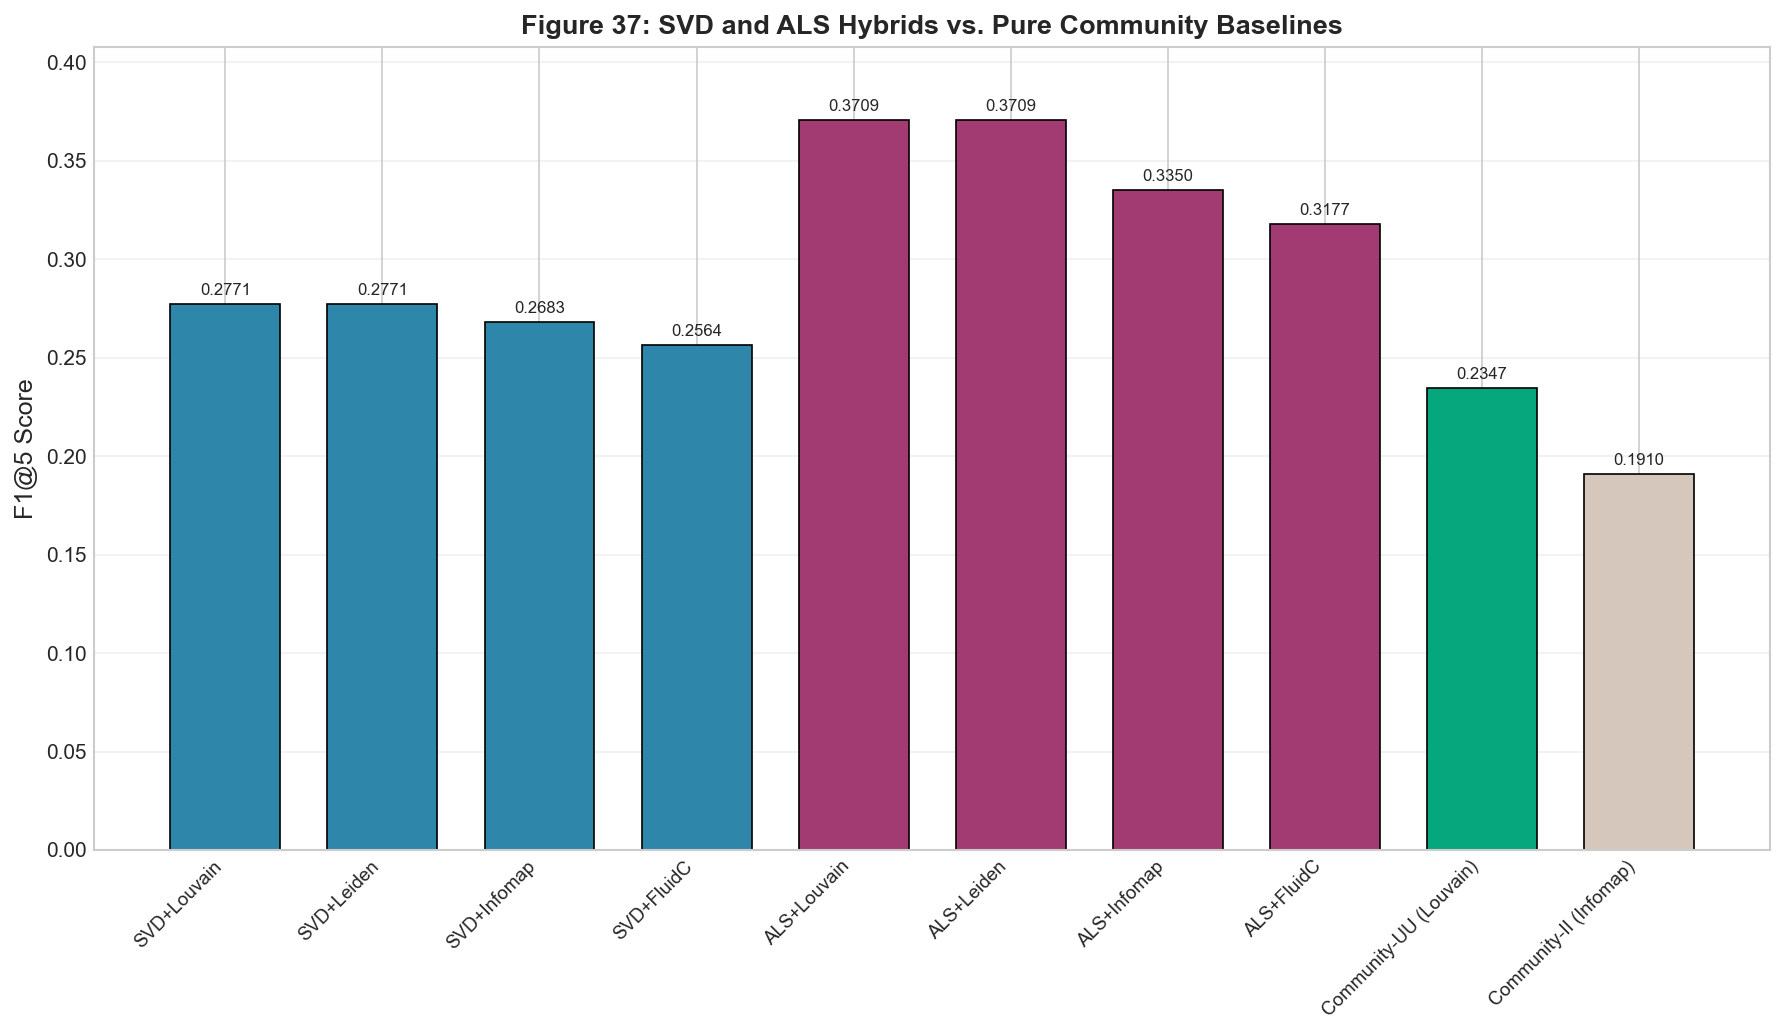

✓ Figure 37 saved



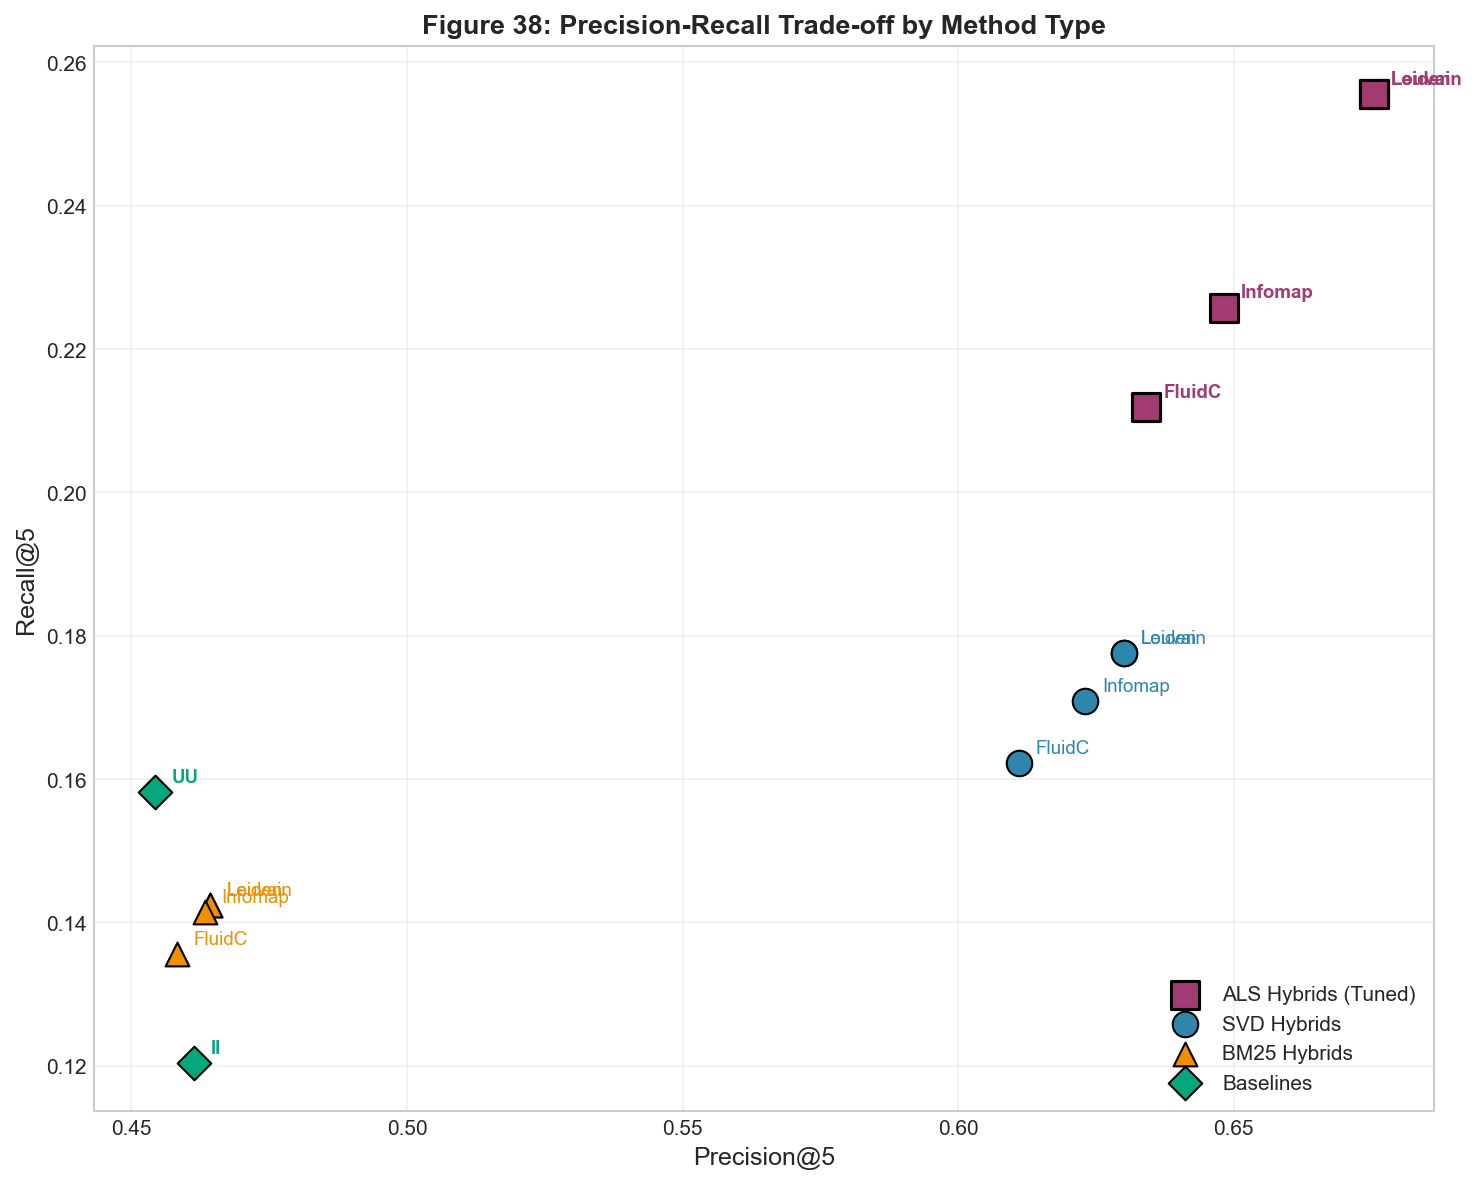

✓ Figure 38 saved



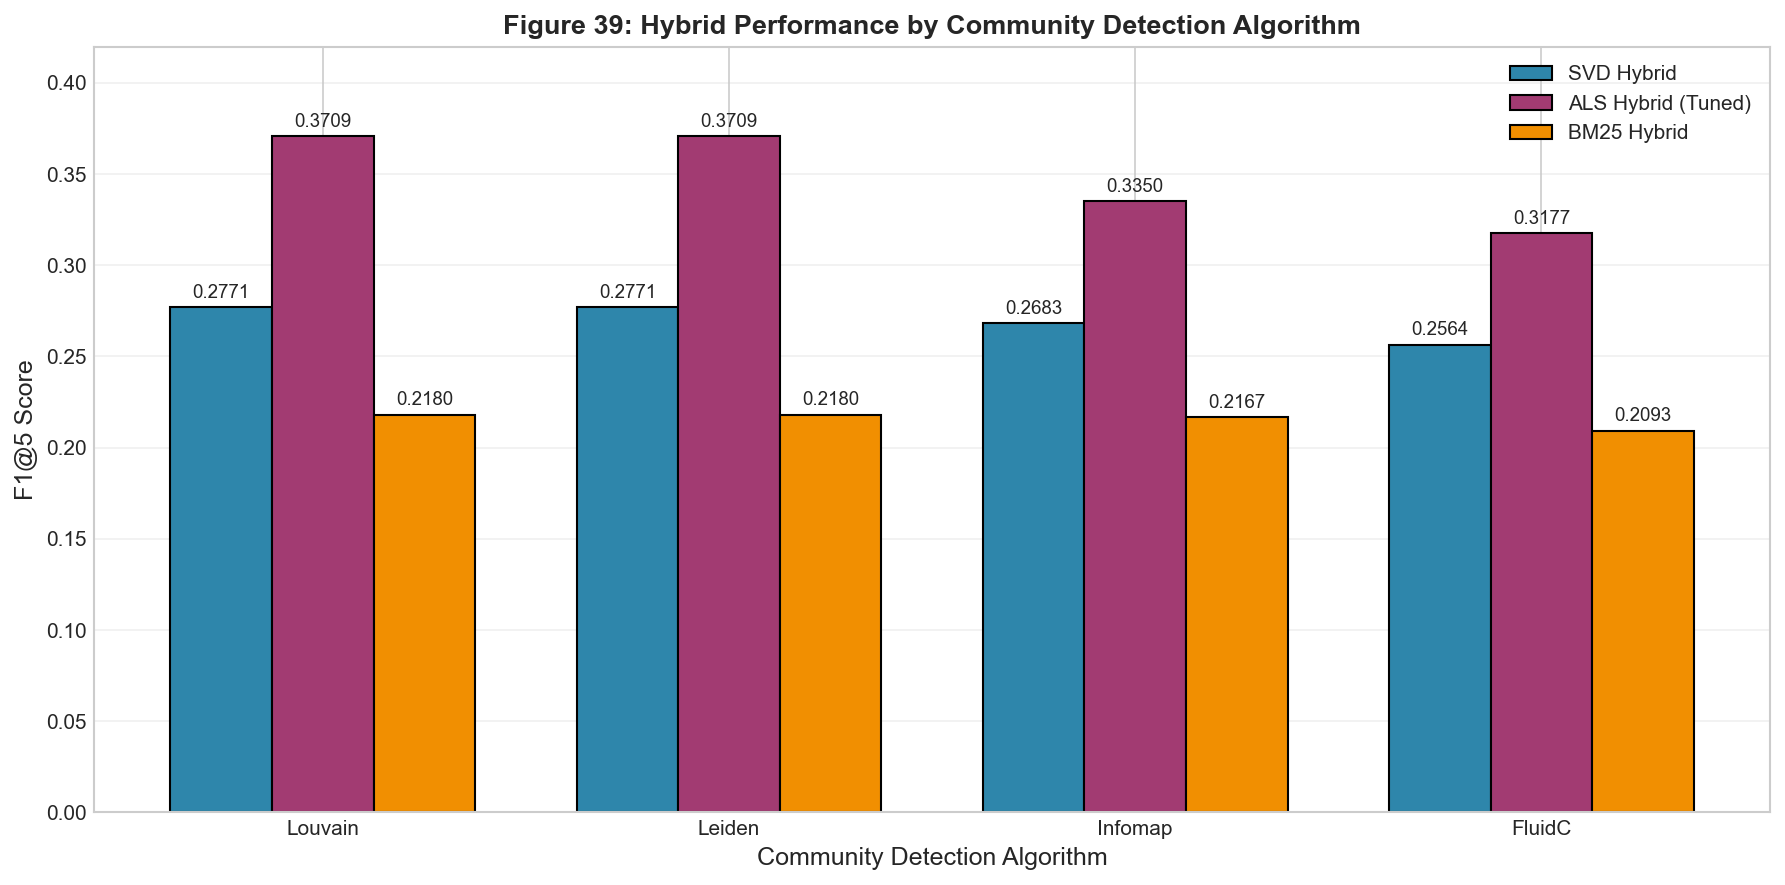

✓ Figure 39 saved



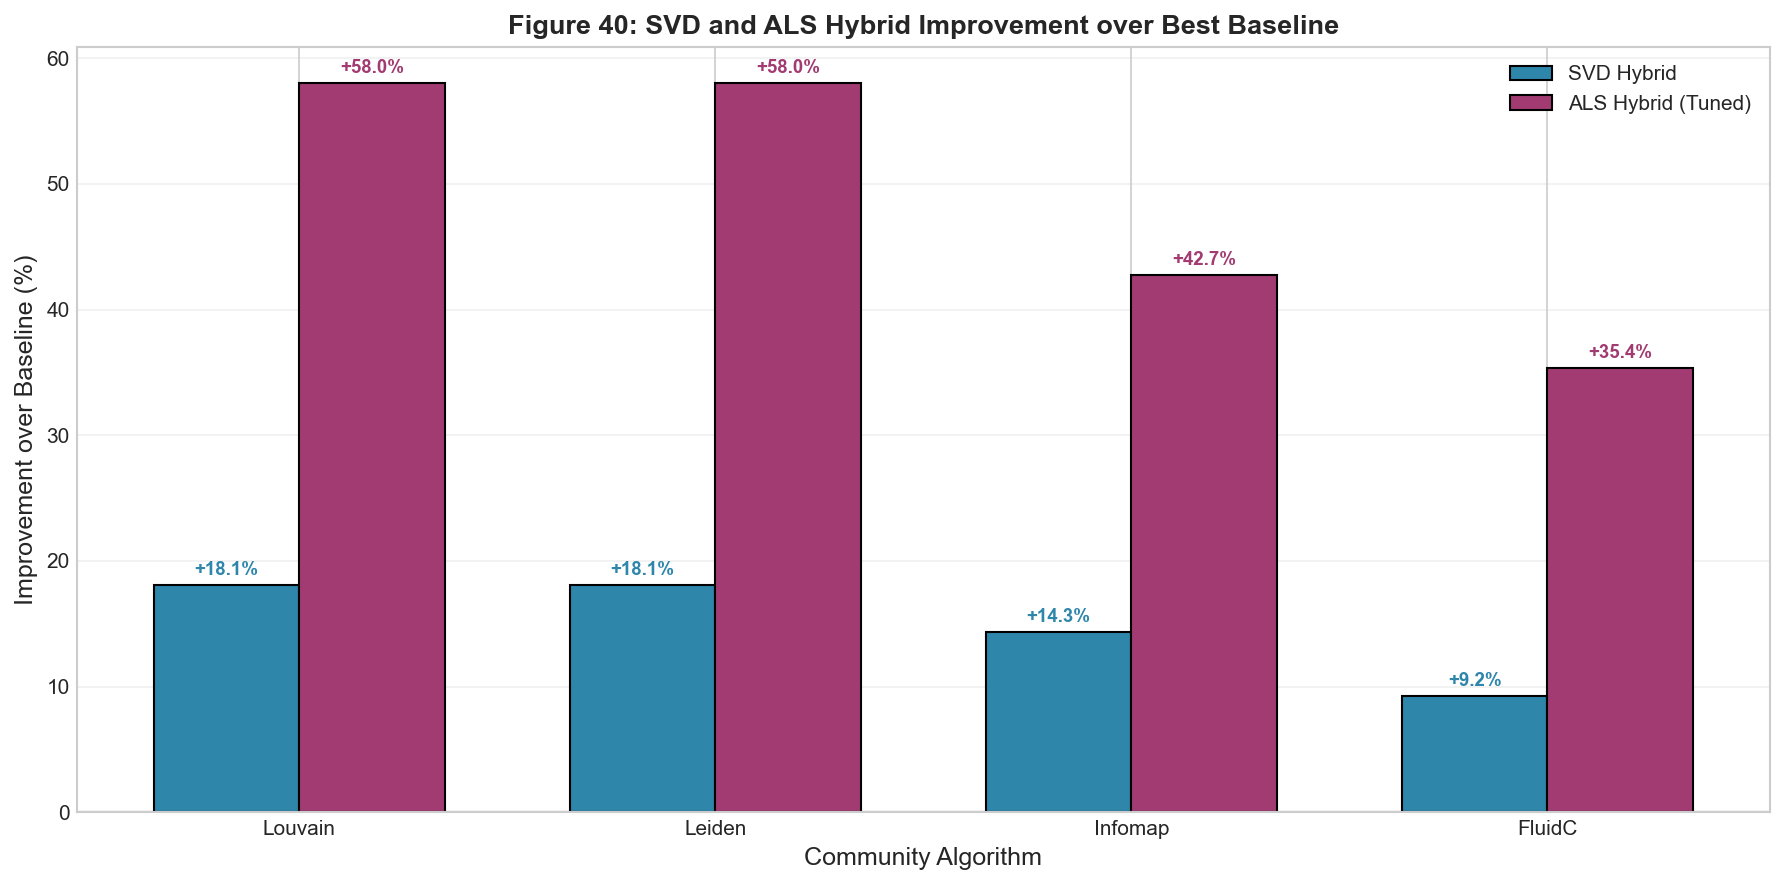

✓ Figure 40 saved


SUMMARY STATISTICS FOR REPORT

📊 BEST PERFORMING METHOD:
   → ALS+Louvain
   → F1@5 = 0.3709
   → Precision@5 = 0.6754
   → Recall@5 = 0.2556
   → Improvement over baseline: +58.0%

📊 SVD HYBRID PERFORMANCE (vs Baseline F1@5=0.2347):
   → SVD+Louvain: F1@5=0.2771 (Δ = +18.1%)
   → SVD+Leiden: F1@5=0.2771 (Δ = +18.1%)
   → SVD+Infomap: F1@5=0.2683 (Δ = +14.3%)
   → SVD+FluidC: F1@5=0.2564 (Δ = +9.2%)

📊 ALS HYBRID PERFORMANCE (vs Baseline F1@5=0.2347):
   → ALS+Louvain: F1@5=0.3709 (Δ = +58.0%)
   → ALS+Leiden: F1@5=0.3709 (Δ = +58.0%)
   → ALS+Infomap: F1@5=0.3350 (Δ = +42.7%)
   → ALS+FluidC: F1@5=0.3177 (Δ = +35.4%)

📊 BM25 HYBRID PERFORMANCE (vs Baseline F1@5=0.2347):
   → BM25+Louvain: F1@5=0.2180 (Δ = -7.1%)
   → BM25+Leiden: F1@5=0.2180 (Δ = -7.1%)
   → BM25+Infomap: F1@5=0.2167 (Δ = -7.7%)
   → BM25+FluidC: F1@5=0.2093 (Δ = -10.8%)

✅ All figures generated successfully!
📁 Files: figure36_*.pdf/png, figure37_*.pdf/png, figure38_*.pdf/png, figure39_*.pdf/png, f

In [2]:
# ============================================================
# COMPLETE VISUALIZATION CODE FOR UPDATED RESULTS
# Run this after saving hybrid_community_results.csv
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional style for report figures
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9

# Load your saved results
df_results = pd.read_csv('als.csv', index_col=0)

print("=== Loaded Results ===\n")
print(df_results[['Precision@5', 'Recall@5', 'F1@5']].to_string())
print("\n" + "="*60 + "\n")

# ============================================================
# FIGURE 36: Bar Chart - F1@5 Comparison (All Methods)
# ============================================================

fig1, ax1 = plt.subplots(figsize=(14, 7))

# Sort by F1@5 descending
df_sorted = df_results.sort_values('F1@5', ascending=False)

colors = []
for method in df_sorted.index:
    if 'ALS+' in method:
        colors.append('#A23B72')  # Purple for ALS hybrids (now best)
    elif 'SVD+' in method:
        colors.append('#2E86AB')  # Blue for SVD hybrids
    elif 'BM25+' in method:
        colors.append('#F18F01')  # Orange for BM25 hybrids
    elif 'Community-UU' in method:
        colors.append('#06A77D')  # Green for User-User baseline
    else:
        colors.append('#D5C7BC')  # Light brown for Item-Item baseline

bars = ax1.bar(range(len(df_sorted)), df_sorted['F1@5'].values, color=colors, edgecolor='black', linewidth=0.8)
ax1.set_xticks(range(len(df_sorted)))
ax1.set_xticklabels(df_sorted.index, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('F1@5 Score', fontsize=12)
ax1.set_title('Figure 36: F1@5 Comparison of All Recommender Approaches', fontsize=14, fontweight='bold')
ax1.set_ylim(0, max(df_sorted['F1@5']) * 1.15)

# Add baseline reference line
baseline_f1 = df_results.loc['Community-UU (Louvain)', 'F1@5']
ax1.axhline(y=baseline_f1, color='red', linestyle='--', linewidth=1.5, 
            label=f"Best Baseline (F1@5={baseline_f1:.4f})")

# Add value labels on bars
for i, (idx, row) in enumerate(df_sorted.iterrows()):
    ax1.text(i, row['F1@5'] + 0.003, f"{row['F1@5']:.4f}", ha='center', va='bottom', fontsize=8)

ax1.legend(loc='upper right')
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figure36_f1_comparison.pdf', format='pdf', bbox_inches='tight')
plt.savefig('figure36_f1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 36 saved\n")

# ============================================================
# FIGURE 37: Hybrids vs Baselines (SVD + ALS)
# ============================================================

fig2, ax2 = plt.subplots(figsize=(12, 7))

# Extract methods
svd_methods = ['SVD+Louvain', 'SVD+Leiden', 'SVD+Infomap', 'SVD+FluidC']
als_methods = ['ALS+Louvain', 'ALS+Leiden', 'ALS+Infomap', 'ALS+FluidC']
baseline_methods = ['Community-UU (Louvain)', 'Community-II (Infomap)']
selected_methods = svd_methods + als_methods + baseline_methods
df_selected = df_results.loc[selected_methods].copy()

x = np.arange(len(selected_methods))
width = 0.7

colors_bar2 = ['#2E86AB'] * 4 + ['#A23B72'] * 4 + ['#06A77D', '#D5C7BC']
bars2 = ax2.bar(x, df_selected['F1@5'], width, color=colors_bar2, edgecolor='black', linewidth=0.8)

ax2.set_xticks(x)
ax2.set_xticklabels(selected_methods, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('F1@5 Score', fontsize=12)
ax2.set_title('Figure 37: SVD and ALS Hybrids vs. Pure Community Baselines', fontweight='bold', fontsize=13)
ax2.set_ylim(0, max(df_selected['F1@5']) * 1.1)

# Add value labels
for i, (idx, row) in enumerate(df_selected.iterrows()):
    ax2.text(i, row['F1@5'] + 0.003, f"{row['F1@5']:.4f}", ha='center', va='bottom', fontsize=8)

ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figure37_svd_als_hybrids.pdf', format='pdf', bbox_inches='tight')
plt.savefig('figure37_svd_als_hybrids.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 37 saved\n")

# ============================================================
# FIGURE 38: Precision-Recall Scatter Plot
# ============================================================

fig3, ax3 = plt.subplots(figsize=(10, 8))

# Categorize methods
svd_methods_all = [m for m in df_results.index if 'SVD+' in m]
als_methods_all = [m for m in df_results.index if 'ALS+' in m]
bm25_methods_all = [m for m in df_results.index if 'BM25+' in m]
baseline_methods_all = [m for m in df_results.index if 'Community' in m]

# Plot ALS hybrids (now highlighted)
for method in als_methods_all:
    p5 = df_results.loc[method, 'Precision@5']
    r5 = df_results.loc[method, 'Recall@5']
    ax3.scatter(p5, r5, c='#A23B72', marker='s', s=180, edgecolor='black', linewidth=1.5,
                label='ALS Hybrids (Tuned)' if method == als_methods_all[0] else "")
    ax3.annotate(method.replace('ALS+', ''), (p5, r5), xytext=(8, 5), textcoords='offset points',
                fontsize=9, fontweight='bold', color='#A23B72')

# Plot SVD hybrids
for method in svd_methods_all:
    p5 = df_results.loc[method, 'Precision@5']
    r5 = df_results.loc[method, 'Recall@5']
    ax3.scatter(p5, r5, c='#2E86AB', marker='o', s=150, edgecolor='black', linewidth=1,
                label='SVD Hybrids' if method == svd_methods_all[0] else "")
    ax3.annotate(method.replace('SVD+', ''), (p5, r5), xytext=(8, 5), textcoords='offset points',
                fontsize=9, color='#2E86AB')

# Plot BM25 hybrids
for method in bm25_methods_all:
    p5 = df_results.loc[method, 'Precision@5']
    r5 = df_results.loc[method, 'Recall@5']
    ax3.scatter(p5, r5, c='#F18F01', marker='^', s=130, edgecolor='black', linewidth=1,
                label='BM25 Hybrids' if method == bm25_methods_all[0] else "")
    ax3.annotate(method.replace('BM25+', ''), (p5, r5), xytext=(8, 5), textcoords='offset points',
                fontsize=9, color='#F18F01')

# Plot Baselines
for method in baseline_methods_all:
    p5 = df_results.loc[method, 'Precision@5']
    r5 = df_results.loc[method, 'Recall@5']
    label = 'Baselines' if method == baseline_methods_all[0] else ""
    ax3.scatter(p5, r5, c='#06A77D', marker='D', s=130, edgecolor='black', linewidth=1, label=label)
    ax3.annotate('UU' if 'UU' in method else 'II', (p5, r5), xytext=(8, 5), textcoords='offset points',
                fontsize=9, fontweight='bold', color='#06A77D')

ax3.set_xlabel('Precision@5', fontsize=12)
ax3.set_ylabel('Recall@5', fontsize=12)
ax3.set_title('Figure 38: Precision-Recall Trade-off by Method Type', fontweight='bold', fontsize=13)
ax3.grid(True, alpha=0.3)
ax3.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('figure38_pr_scatter.pdf', format='pdf', bbox_inches='tight')
plt.savefig('figure38_pr_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 38 saved\n")

# ============================================================
# FIGURE 39: Performance by Community Algorithm
# ============================================================

fig4, ax4 = plt.subplots(figsize=(12, 6))

algorithms = ['Louvain', 'Leiden', 'Infomap', 'FluidC']
x4 = np.arange(len(algorithms))
width4 = 0.25

svd_scores = [df_results.loc[f'SVD+{a}', 'F1@5'] for a in algorithms]
als_scores = [df_results.loc[f'ALS+{a}', 'F1@5'] for a in algorithms]
bm25_scores = [df_results.loc[f'BM25+{a}', 'F1@5'] for a in algorithms]

bars_svd = ax4.bar(x4 - width4, svd_scores, width4, label='SVD Hybrid', color='#2E86AB', edgecolor='black')
bars_als = ax4.bar(x4, als_scores, width4, label='ALS Hybrid (Tuned)', color='#A23B72', edgecolor='black')
bars_bm25 = ax4.bar(x4 + width4, bm25_scores, width4, label='BM25 Hybrid', color='#F18F01', edgecolor='black')

ax4.set_xlabel('Community Detection Algorithm', fontsize=12)
ax4.set_ylabel('F1@5 Score', fontsize=12)
ax4.set_title('Figure 39: Hybrid Performance by Community Detection Algorithm', fontweight='bold', fontsize=13)
ax4.set_xticks(x4)
ax4.set_xticklabels(algorithms)
ax4.set_ylim(0, 0.42)
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for bars, scores in [(bars_svd, svd_scores), (bars_als, als_scores), (bars_bm25, bm25_scores)]:
    for bar, score in zip(bars, scores):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, 
                f'{score:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('figure39_by_algorithm.pdf', format='pdf', bbox_inches='tight')
plt.savefig('figure39_by_algorithm.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 39 saved\n")

# ============================================================
# FIGURE 40: Improvement Over Baseline (SVD + ALS)
# ============================================================

fig5, ax5 = plt.subplots(figsize=(12, 6))

baseline_f1 = df_results.loc['Community-UU (Louvain)', 'F1@5']

# SVD methods
svd_methods_only = ['SVD+Louvain', 'SVD+Leiden', 'SVD+Infomap', 'SVD+FluidC']
svd_improvements_pct = [((df_results.loc[m, 'F1@5'] - baseline_f1) / baseline_f1) * 100 for m in svd_methods_only]

# ALS methods
als_methods_only = ['ALS+Louvain', 'ALS+Leiden', 'ALS+Infomap', 'ALS+FluidC']
als_improvements_pct = [((df_results.loc[m, 'F1@5'] - baseline_f1) / baseline_f1) * 100 for m in als_methods_only]

method_names = ['Louvain', 'Leiden', 'Infomap', 'FluidC']

x5 = np.arange(len(method_names))
width5 = 0.35

bars_svd_imp = ax5.bar(x5 - width5/2, svd_improvements_pct, width5, label='SVD Hybrid', color='#2E86AB', edgecolor='black')
bars_als_imp = ax5.bar(x5 + width5/2, als_improvements_pct, width5, label='ALS Hybrid (Tuned)', color='#A23B72', edgecolor='black')

ax5.axhline(y=0, color='black', linewidth=1)
ax5.set_xlabel('Community Algorithm', fontsize=12)
ax5.set_ylabel('Improvement over Baseline (%)', fontsize=12)
ax5.set_title('Figure 40: SVD and ALS Hybrid Improvement over Best Baseline', fontweight='bold', fontsize=13)
ax5.set_xticks(x5)
ax5.set_xticklabels(method_names)
ax5.legend(fontsize=10)
ax5.grid(axis='y', alpha=0.3)

# Add value labels for SVD
for bar, imp in zip(bars_svd_imp, svd_improvements_pct):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'+{imp:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#2E86AB')

# Add value labels for ALS
for bar, imp in zip(bars_als_imp, als_improvements_pct):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'+{imp:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#A23B72')

plt.tight_layout()
plt.savefig('figure40_improvement.pdf', format='pdf', bbox_inches='tight')
plt.savefig('figure40_improvement.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Figure 40 saved\n")

# ============================================================
# PRINT SUMMARY STATISTICS FOR REPORT
# ============================================================

print("\n" + "="*70)
print("SUMMARY STATISTICS FOR REPORT")
print("="*70)

best_overall = df_results['F1@5'].idxmax()
best_f1 = df_results.loc[best_overall, 'F1@5']
best_baseline = 'Community-UU (Louvain)'
baseline_f1_val = df_results.loc[best_baseline, 'F1@5']
improvement_pct = ((best_f1 - baseline_f1_val) / baseline_f1_val) * 100

print(f"\n📊 BEST PERFORMING METHOD:")
print(f"   → {best_overall}")
print(f"   → F1@5 = {best_f1:.4f}")
print(f"   → Precision@5 = {df_results.loc[best_overall, 'Precision@5']:.4f}")
print(f"   → Recall@5 = {df_results.loc[best_overall, 'Recall@5']:.4f}")
print(f"   → Improvement over baseline: +{improvement_pct:.1f}%\n")

print("📊 SVD HYBRID PERFORMANCE (vs Baseline F1@5=0.2347):")
for method in svd_methods_only:
    f1 = df_results.loc[method, 'F1@5']
    imp = ((f1 - baseline_f1_val) / baseline_f1_val) * 100
    print(f"   → {method}: F1@5={f1:.4f} (Δ = +{imp:.1f}%)")

print("\n📊 ALS HYBRID PERFORMANCE (vs Baseline F1@5=0.2347):")
for method in als_methods_only:
    f1 = df_results.loc[method, 'F1@5']
    imp = ((f1 - baseline_f1_val) / baseline_f1_val) * 100
    print(f"   → {method}: F1@5={f1:.4f} (Δ = +{imp:.1f}%)")

print("\n📊 BM25 HYBRID PERFORMANCE (vs Baseline F1@5=0.2347):")
for method in bm25_methods_all:
    f1 = df_results.loc[method, 'F1@5']
    imp = ((f1 - baseline_f1_val) / baseline_f1_val) * 100
    print(f"   → {method}: F1@5={f1:.4f} (Δ = {imp:+.1f}%)")

print("\n" + "="*70)
print("✅ All figures generated successfully!")
print("📁 Files: figure36_*.pdf/png, figure37_*.pdf/png, figure38_*.pdf/png, figure39_*.pdf/png, figure40_*.pdf/png")